In [37]:
#==============================================================================
# IPL DATA ANALYSIS PROJECT (2008-24)
# TOOLS = NUMPY, PANDAS, SEABORN, MATPLOTLIB
# AUTHOR = ADITYA KUMAR 
#==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set_theme(style = 'darkgrid')
%matplotlib inline
os.makedirs('charts', exist_ok = True)
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')
print(f'matches: {matches.shape}')
print(f'deliveries: {deliveries.shape}')

matches: (1095, 20)
deliveries: (225954, 17)


# Exploring data

In [11]:
print(matches.columns.tolist())
print(deliveries.columns.tolist())
matches.head(5)

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler', 'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run', 'non_boundary', 'isWicketDelivery', 'player_out', 'kind', 'fielders_involved', 'BattingTeam']


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


## checking missing values

In [13]:
print(matches.isnull().sum())
print(deliveries.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64
ID                        0
innings                   0
overs                     0
ballnumber                0
batter                    0
bowler                    0
non-striker               0
extra_type           213905
batsman_run               0
extras_run                0
total_run                 0
non_boundary              0
isWicketDelivery          0
player_out           214803
kind                 214803
fielders_involved    217966
BattingTeam               0
dtype: int64


## data cleaning

In [25]:
# auto-fix columnn name( some datasets use batter instead of batsman)
if 'batter' in deliveries.columns:
    deliveries = deliveries.rename(columns={'batter':'batsman'})
    print('Renamed batter to batsman')

matches_clean = matches.dropna(subset=['winner']).copy()
matches_clean['winner']= matches_clean['winner'].str.strip()
matches_clean['team1'] = matches_clean['team1'].str.strip()
matches_clean['team2'] = matches_clean['team2'].str.strip()
matches_clean['toss_winner'] = matches_clean['toss_winner'].str.strip()
deliveries['player_out'] = deliveries['player_out'].fillna('not out')
print(f'matches after cleaning: {matches_clean.shape[0]}')

matches after cleaning: 1090


# analysis 1
## matches per season

C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\3886000956.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=matches_per_season, x = 'season', y = 'total_matches', palette = 'Set1')


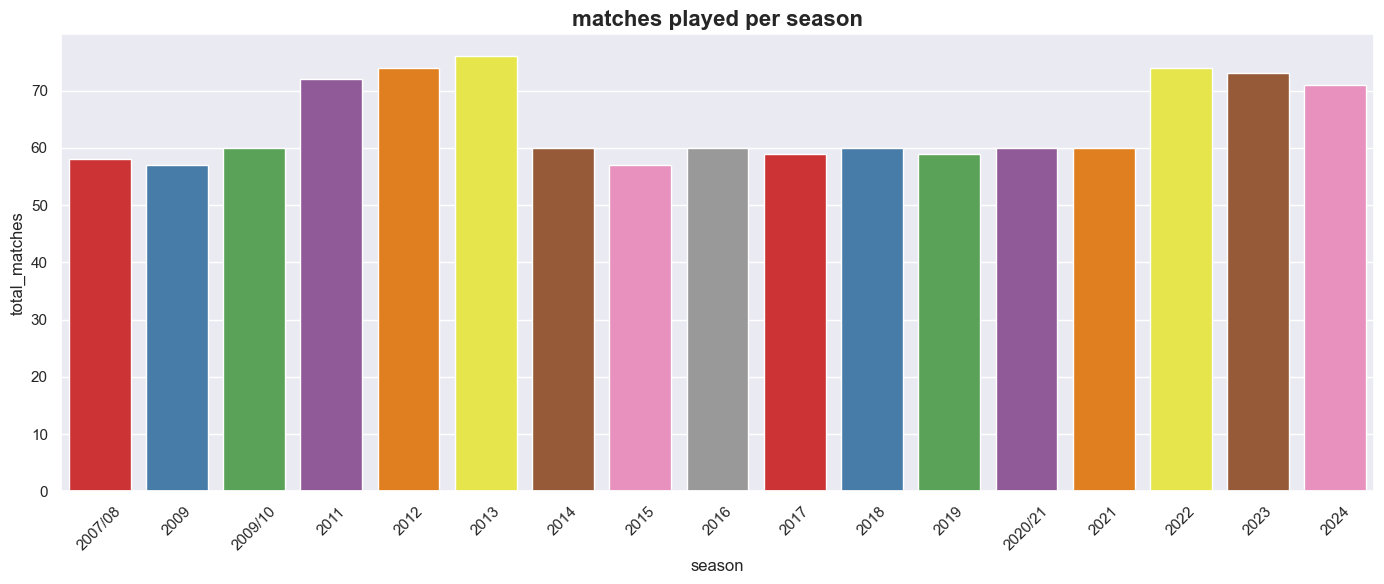

In [40]:
matches_per_season = matches_clean.groupby('season')['id'].count().reset_index()
matches_per_season.columns = ('season', 'total_matches')
plt.figure(figsize = (14, 6))
sns.barplot(data=matches_per_season, x = 'season', y = 'total_matches', palette = 'Set1')
plt.title('matches played per season', fontsize = 16, fontweight = 'bold')
plt.xlabel('season')
plt.ylabel('total_matches')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig('charts/01_matches_per_id.png', dpi =150)
plt.show()

C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\3714960195.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_wins.head(10), x='Wins', y='Team', palette='rocket')


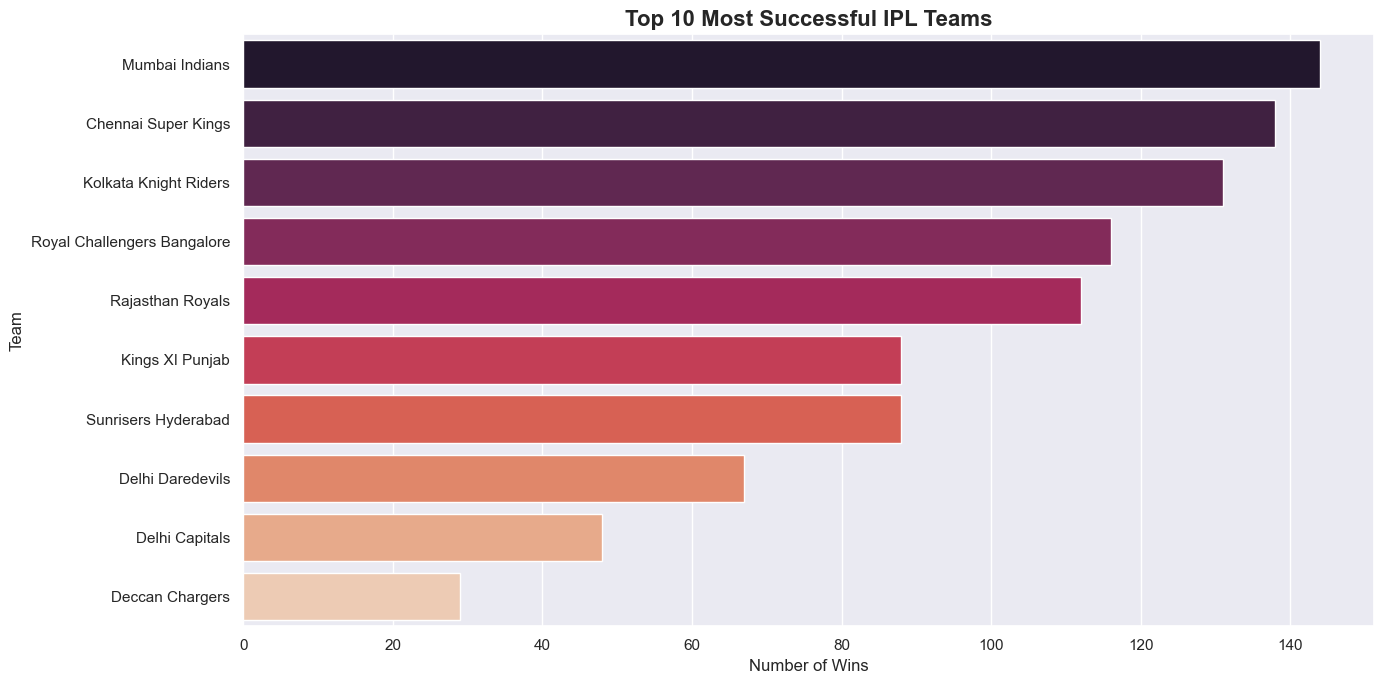

In [42]:
# 2
team_wins = matches_clean['winner'].value_counts().reset_index()
team_wins.columns = ['Team', 'Wins']

plt.figure(figsize=(14, 7))
sns.barplot(data=team_wins.head(10), x='Wins', y='Team', palette='rocket')
plt.title('Top 10 Most Successful IPL Teams', fontsize=16, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('charts/02_team_wins.png', dpi=150)
plt.show()

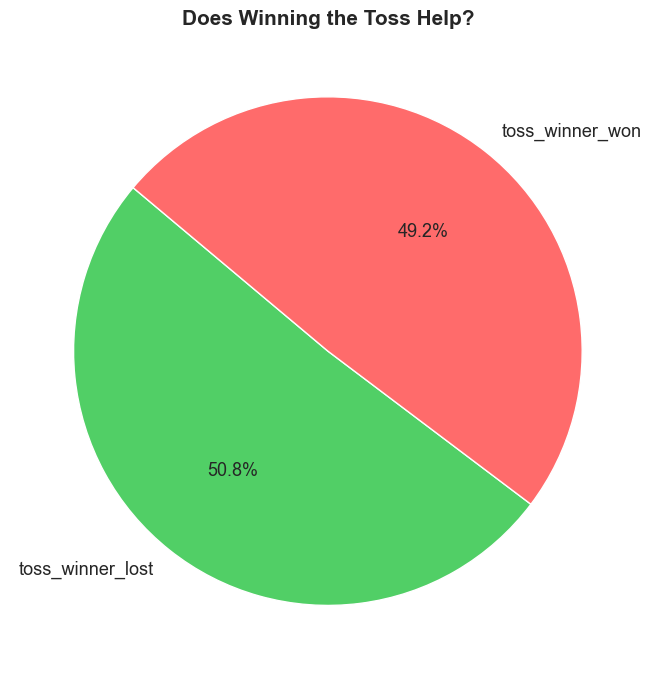

In [46]:
# 3 toss impact
matches_clean['toss_win_match_win'] = (matches_clean['toss_winner'] == matches_clean['winner'])
toss_counts = matches_clean['toss_win_match_win'].value_counts()
plt.figure(figsize = (7,7))
plt.pie(toss_counts.values,
        labels =['toss_winner_lost', 'toss_winner_won'],
        autopct = '%1.1f%%',
        colors=['#51cf66', '#ff6b6b'],
        startangle = 140,
        textprops ={'fontsize': 13})
plt.title('Does Winning the Toss Help?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_toss_impact.png', dpi=150)
plt.show()


C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\1753465883.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=batsman_run.head(10), x='Total Runs', y='Batter', palette='magma')


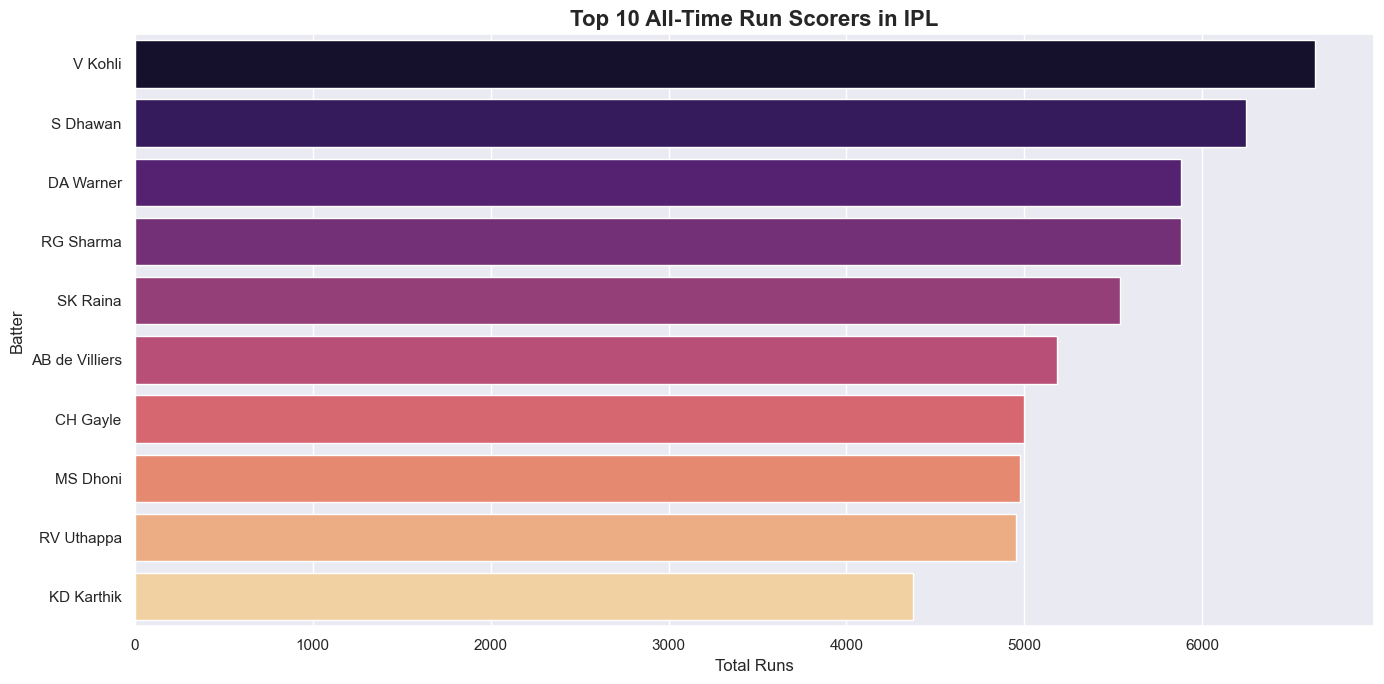

In [50]:
#4 top 10 run scorers
batsman_run = deliveries.groupby('batter')['batsman_run'].sum().reset_index()
batsman_run.columns = ['Batter', 'Total Runs']
batsman_run = batsman_run.sort_values('Total Runs', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=batsman_run.head(10), x='Total Runs', y='Batter', palette='magma')
plt.title('Top 10 All-Time Run Scorers in IPL', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/04_top_batsmen.png', dpi=150)
plt.show()

C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\2743714002.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bowler_wickets.head(10), x='Wickets', y='Bowler', palette='viridis')


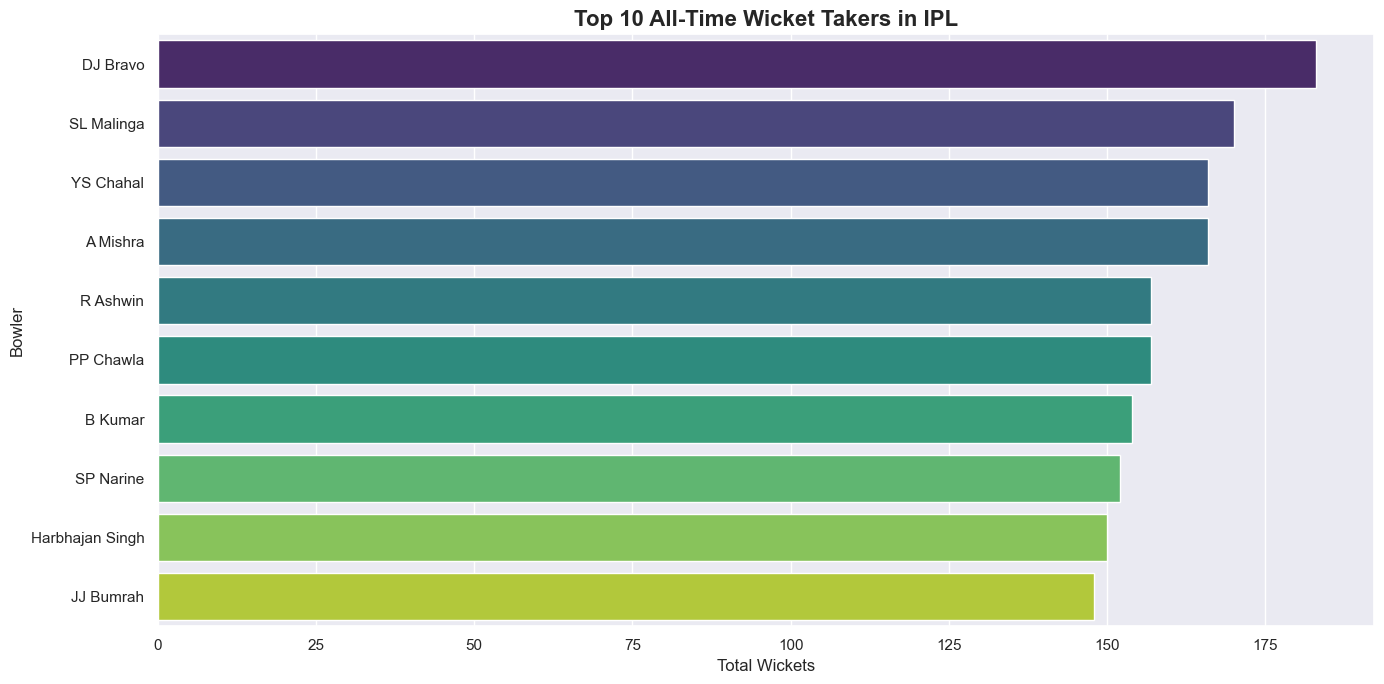

In [58]:
#5 top 10 most wicket taker
wickets = deliveries[deliveries
    ['kind'].notna() & 
     ~deliveries['kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
bowler_wickets = wickets.groupby('bowler')['player_out'].count().reset_index()
bowler_wickets.columns = ['Bowler', 'Wickets']
bowler_wickets = bowler_wickets.sort_values('Wickets', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=bowler_wickets.head(10), x='Wickets', y='Bowler', palette='viridis')
plt.title('Top 10 All-Time Wicket Takers in IPL', fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('charts/05_top_bowlers.png', dpi=150)
plt.show()

C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\523679736.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=batsman_stats.head(10), x='Strike Rate', y='Batter', palette='coolwarm')


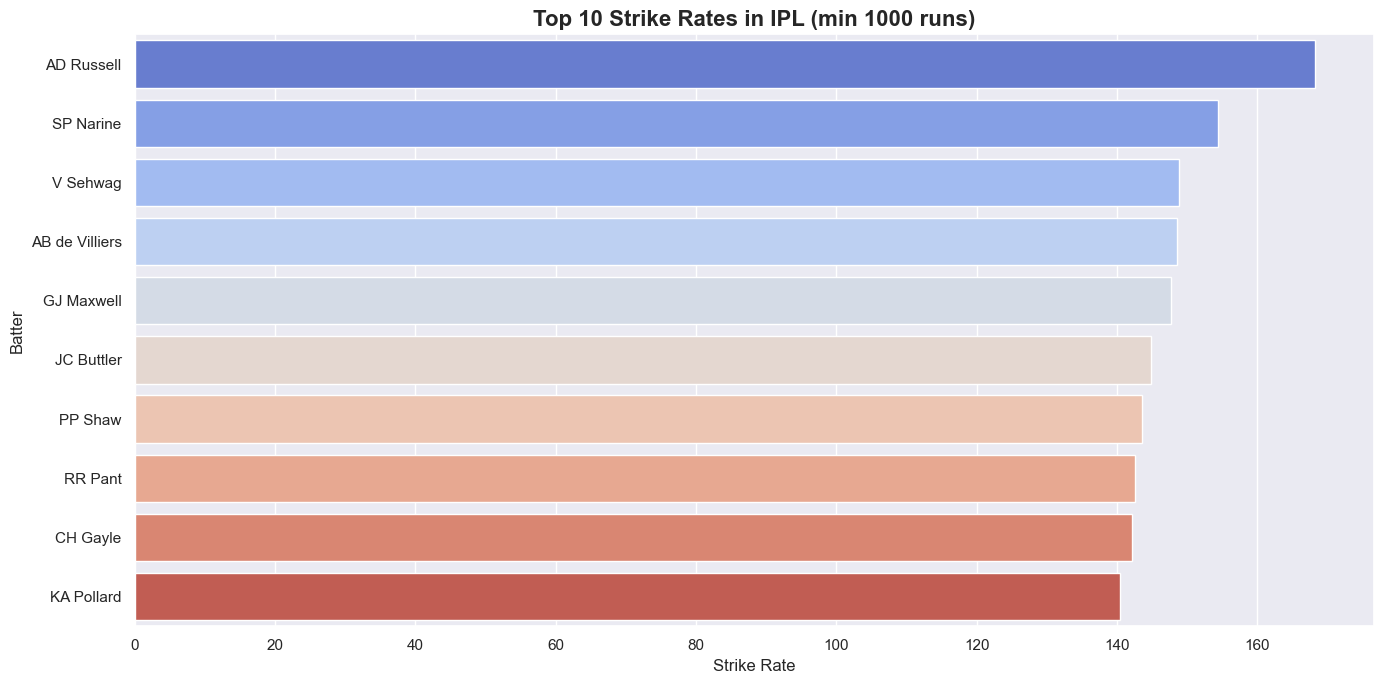

In [63]:
#6 best strike rates
balls_faced = deliveries.groupby('batter')['ballnumber'].count().reset_index()
balls_faced.columns = ['Batter', 'Balls Faced']

batsman_stats = batsman_run.merge(balls_faced, on='Batter')
batsman_stats['Strike Rate'] = ((batsman_stats['Total Runs'] / batsman_stats['Balls Faced']) * 100).round(2)
batsman_stats = batsman_stats[batsman_stats['Total Runs'] >= 1000]
batsman_stats = batsman_stats.sort_values('Strike Rate', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=batsman_stats.head(10), x='Strike Rate', y='Batter', palette='coolwarm')
plt.title('Top 10 Strike Rates in IPL (min 1000 runs)', fontsize=16, fontweight='bold')
plt.xlabel('Strike Rate')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/06_strike_rates.png', dpi=150)
plt.show()

C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\2264383685.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bowler_stats.head(10), x='Economy', y='Bowler', palette='YlGn_r')


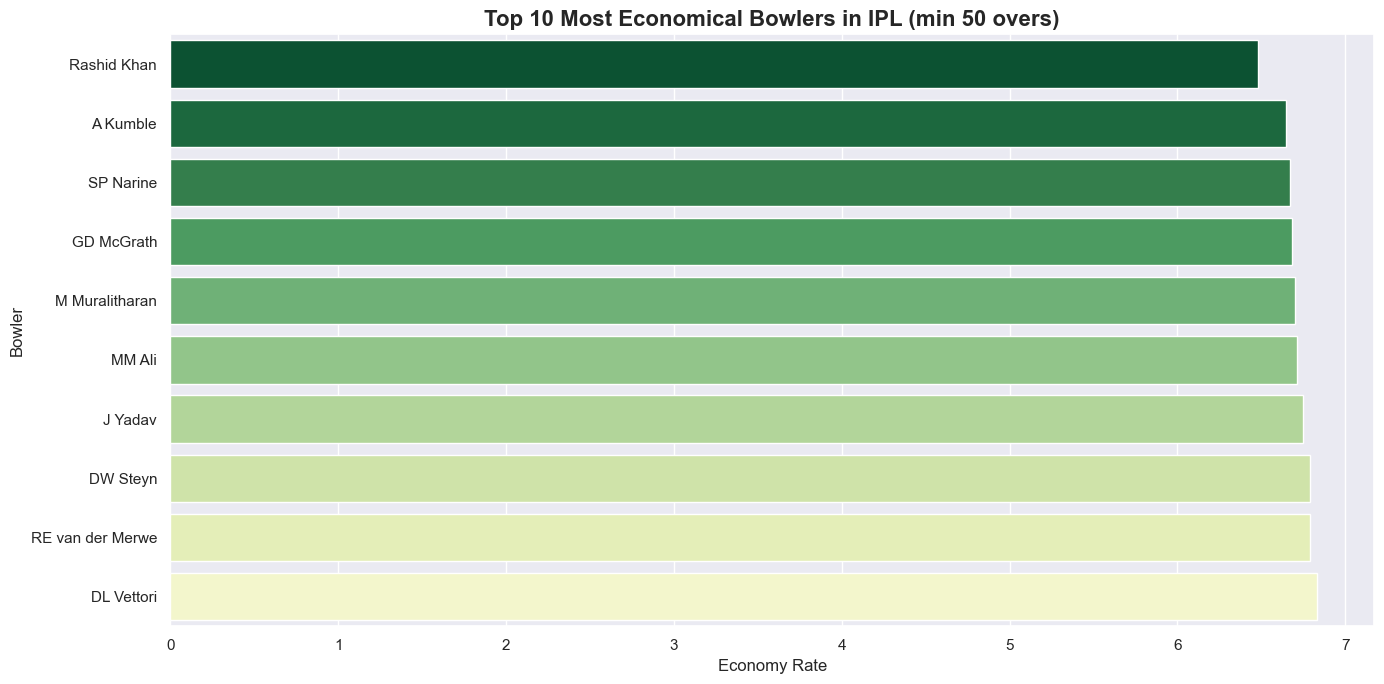

In [66]:
#7 most economical bowlers
runs_given = deliveries.groupby('bowler')['total_run'].sum().reset_index()
runs_given.columns = ['Bowler', 'Runs Given']

balls_bowled = deliveries.groupby('bowler')['ballnumber'].count().reset_index()
balls_bowled.columns = ['Bowler', 'Balls Bowled']

bowler_stats = bowler_wickets.merge(runs_given, on='Bowler').merge(balls_bowled, on='Bowler')
bowler_stats['Overs'] = (bowler_stats['Balls Bowled'] / 6).round(2)
bowler_stats['Economy'] = (bowler_stats['Runs Given'] / bowler_stats['Overs']).round(2)
bowler_stats = bowler_stats[bowler_stats['Overs'] >= 50]
bowler_stats = bowler_stats.sort_values('Economy', ascending=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=bowler_stats.head(10), x='Economy', y='Bowler', palette='YlGn_r')
plt.title('Top 10 Most Economical Bowlers in IPL (min 50 overs)', fontsize=16, fontweight='bold')
plt.xlabel('Economy Rate')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('charts/07_economy_rates.png', dpi=150)
plt.show()

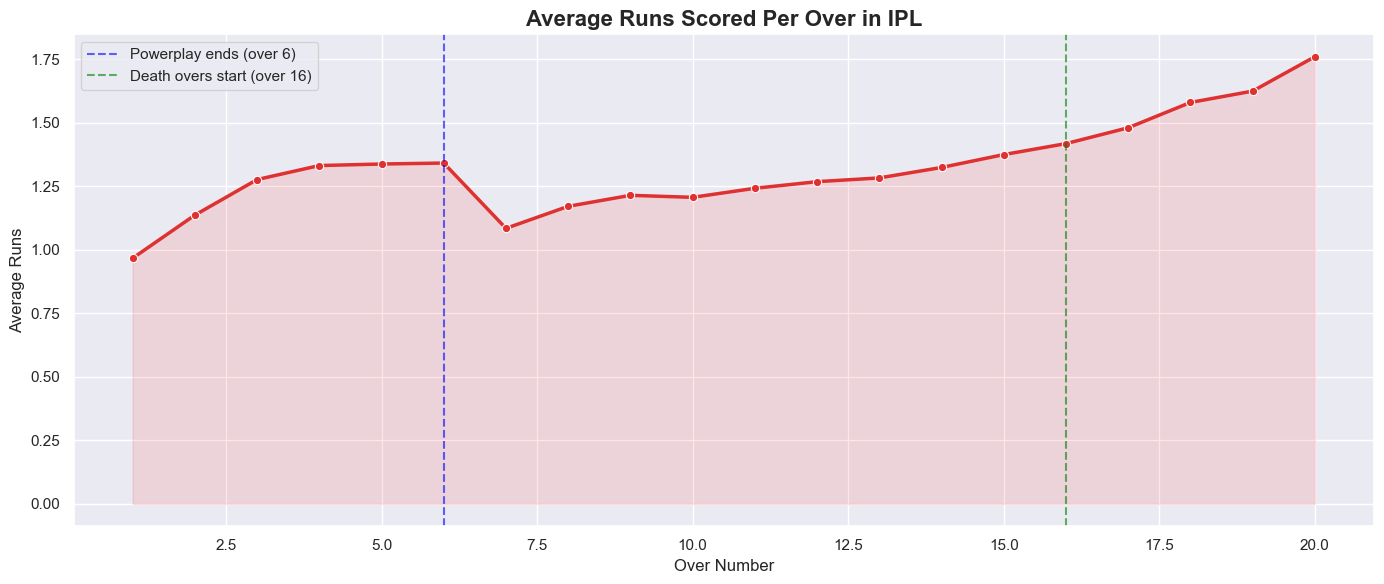

In [69]:
#8 runs per over
runs_per_over = deliveries.groupby('overs')['total_run'].mean().reset_index()
runs_per_over.columns = ['Overs', 'Avg Runs']
runs_per_over['Overs'] = runs_per_over['Overs'] + 1

plt.figure(figsize=(14, 6))
sns.lineplot(data=runs_per_over, x='Overs', y='Avg Runs', color='#e03131', linewidth=2.5, marker='o')
plt.axvline(x=6, color='blue', linestyle='--', alpha=0.6, label='Powerplay ends (over 6)')
plt.axvline(x=16, color='green', linestyle='--', alpha=0.6, label='Death overs start (over 16)')
plt.fill_between(runs_per_over['Overs'], runs_per_over['Avg Runs'], alpha=0.1, color='red')
plt.title('Average Runs Scored Per Over in IPL', fontsize=16, fontweight='bold')
plt.xlabel('Over Number')
plt.ylabel('Average Runs')
plt.legend()
plt.tight_layout()
plt.savefig('charts/08_runs_per_over.png', dpi=150)
plt.show()

C:\Users\Aditya\AppData\Local\Temp\ipykernel_18208\3411320966.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_sixes.head(10), x='Sixes', y='Batter', palette='flare')


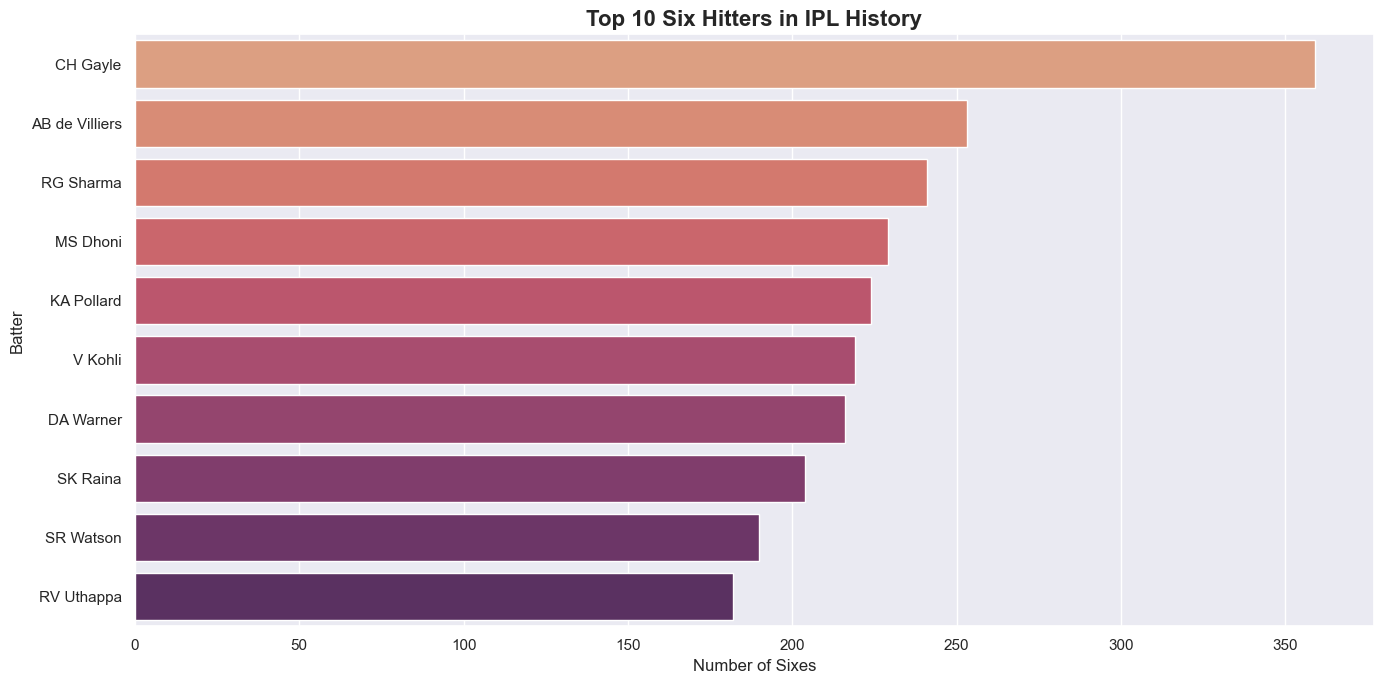

In [70]:
#9 most sixes
sixes = deliveries[deliveries['batsman_run'] == 6]
most_sixes = sixes.groupby('batter')['batsman_run'].count().reset_index()
most_sixes.columns = ['Batter', 'Sixes']
most_sixes = most_sixes.sort_values('Sixes', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=most_sixes.head(10), x='Sixes', y='Batter', palette='flare')
plt.title('Top 10 Six Hitters in IPL History', fontsize=16, fontweight='bold')
plt.xlabel('Number of Sixes')
plt.ylabel('Batter')
plt.tight_layout()
plt.savefig('charts/09_most_sixes.png', dpi=150)
plt.show()

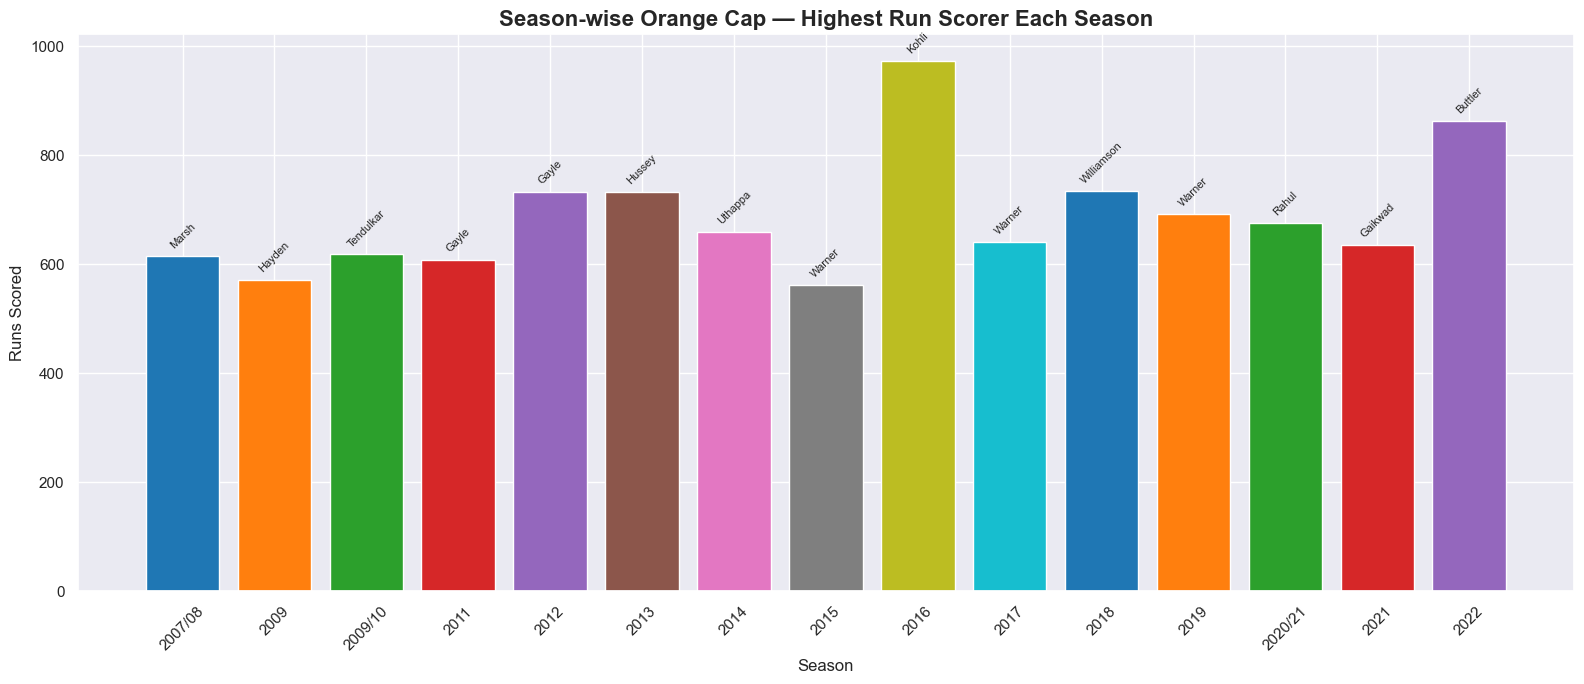

In [84]:
#10 per season orange cap
delivery_season = deliveries.merge(matches_clean[['id', 'season']], left_on= 'ID', right_on='id')
season_runs = delivery_season.groupby(['season', 'batter'])['batsman_run'].sum().reset_index()
season_runs.columns = ['Season', 'Batter', 'Runs']

top_per_season = season_runs.sort_values('Runs', ascending=False).groupby('Season').first().reset_index()

colors = sns.color_palette('tab10', len(top_per_season))
plt.figure(figsize=(16, 7))
bars = plt.bar(top_per_season['Season'].astype(str), top_per_season['Runs'], color=colors)
for bar, (_, row) in zip(bars, top_per_season.iterrows()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             row['Batter'].split()[-1], ha='center', va='bottom', fontsize=8, rotation=45)
plt.title('Season-wise Orange Cap — Highest Run Scorer Each Season', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Runs Scored')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/10_orange_cap.png', dpi=150)
plt.show()

In [88]:
#summary
print('=' * 50)
print('IPL PROJECT SUMMARY')
print('=' * 50)
print(f'Total Seasons    : {matches_clean["season"].nunique()}')
print(f'Total Matches    : {matches_clean.shape[0]}')
print(f'Total Deliveries : {deliveries.shape[0]:,}')
print(f'Unique Batsmen   : {deliveries["batter"].nunique()}')
print(f'Unique Bowlers   : {deliveries["bowler"].nunique()}')
print(f'Best Team        : {team_wins.iloc[0]["Team"]} ({team_wins.iloc[0]["Wins"]} wins)')
print(f'Top Run Scorer   : {batsman_run.iloc[0]["Batter"]} ({batsman_run.iloc[0]["Total Runs"]:,} runs)')
print(f'Top Wicket Taker : {bowler_wickets.iloc[0]["Bowler"]} ({bowler_wickets.iloc[0]["Wickets"]} wickets)')
print(f'Top Six Hitter   : {most_sixes.iloc[0]["Batter"]} ({most_sixes.iloc[0]["Sixes"]} sixes)')
print('=' * 50)

IPL PROJECT SUMMARY
Total Seasons    : 17
Total Matches    : 1090
Total Deliveries : 225,954
Unique Batsmen   : 605
Unique Bowlers   : 472
Best Team        : Mumbai Indians (144 wins)
Top Run Scorer   : V Kohli (6,634 runs)
Top Wicket Taker : DJ Bravo (183 wickets)
Top Six Hitter   : CH Gayle (359 sixes)
